<a href="https://colab.research.google.com/github/DhananjayaFdo/Databases-and-Analytics-Assignment/blob/main/R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load libraries and data

In [1]:
install.packages(c("dplyr", "ggplot2", "tidyr"))

library(dplyr)
library(ggplot2)
library(tidyr)

print("Loading files...")

baseUrl = "https://raw.githubusercontent.com/DhananjayaFdo/Databases-and-Analytics-Assignment/refs/heads/main/northstar_dataset";

hubs <- read.csv(paste0(baseUrl, '/hubs.csv'))
customers <- read.csv(paste0(baseUrl, '/customers.csv'))
drivers <- read.csv(paste0(baseUrl, '/drivers.csv'));
vehicles <- read.csv (paste0(baseUrl, '/vehicles.csv'));
orders  <- read.csv (paste0(baseUrl, '/orders.csv'));
deliveries  <- read.csv (paste0(baseUrl, '/deliveries.csv'));
incidents  <- read.csv (paste0(baseUrl, '/incidents.csv'));
complaints  <- read.csv (paste0(baseUrl, '/complaints.csv'));
app_events <- read.csv (paste0(baseUrl, '/app_events.csv'));

print("All files loaded ✓")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Loading files..."
[1] "All files loaded ✓"


# Clean the data

In [2]:
drivers <- drivers %>%
  mutate(training_score = ifelse(is.na(training_score),
                                 median(training_score, na.rm = TRUE),
                                 training_score))

customers <- customers %>%
  mutate(
    loyalty_score = ifelse(is.na(loyalty_score),
                           median(loyalty_score, na.rm = TRUE),
                           loyalty_score),
    preferred_channel = ifelse(is.na(preferred_channel), "Unknown", preferred_channel)
  )

deliveries <- deliveries %>%
  mutate(customer_rating_post_delivery = ifelse(
    is.na(customer_rating_post_delivery),
    median(customer_rating_post_delivery, na.rm = TRUE),
    customer_rating_post_delivery
  ))

complaints <- complaints %>%
  mutate(compensation_amount = ifelse(is.na(compensation_amount), 0, compensation_amount))

vehicles <- vehicles %>%
  mutate(battery_health_pct = ifelse(is.na(battery_health_pct),
                                     median(battery_health_pct, na.rm = TRUE),
                                     battery_health_pct))

cat("Drivers missing:", sum(is.na(drivers)), "\n")
cat("Customers missing:", sum(is.na(customers)), "\n")
cat("Deliveries missing:", sum(is.na(deliveries)), "\n")
cat("Complaints missing:", sum(is.na(complaints)), "\n")
cat("Vehicles missing:", sum(is.na(vehicles)), "\n")

Drivers missing: 0 
Customers missing: 0 
Deliveries missing: 0 
Complaints missing: 0 
Vehicles missing: 0 


"Missing numeric values were replaced with the median rather than mean to avoid distortion from outliers. Missing categorical values were labelled 'Unknown' to preserve record counts."

# Statistical Analysis

## Summary of delivery performance

In [3]:
delivery_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    count      = n(),
    pct        = round(n() / nrow(deliveries) * 100, 1),
    avg_rating = round(mean(customer_rating_post_delivery), 2),
    avg_cost   = round(mean(fuel_or_charge_cost), 2)
  )

print(delivery_summary)

# A tibble: 3 × 5
  delivery_status count   pct avg_rating avg_cost
  <chr>           <int> <dbl>      <dbl>    <dbl>
1 Delayed           202  21.3       3.14     13.1
2 Failed            132  13.9       3.06     13.2
3 OnTime            616  64.8       4.28     12.7


"Failed and delayed deliveries together account for over 35% of all operations. Failed deliveries also show the lowest customer ratings, confirming that status directly impacts satisfaction."

## Does driver rating relate to delivery failures?

In [4]:
drv_perf <- deliveries %>%
  inner_join(drivers, by = "driver_id") %>%
  group_by(driver_id, driver_rating) %>%
  summarise(
    total     = n(),
    failed    = sum(delivery_status == "Failed"),
    fail_rate = round(failed / total * 100, 1),
    .groups   = "drop"
  )

cor_result <- cor(drv_perf$driver_rating, drv_perf$fail_rate, use = "complete.obs")
cat("Correlation (driver rating vs fail rate):", round(cor_result, 3), "\n")

Correlation (driver rating vs fail rate): -0.236 


"A negative correlation here would confirm that lower-rated drivers produce more failures — supporting the need for NorthStar to invest in driver performance management."

## Summary stats for complaints by severity

In [ ]:
complaint_stats <- complaints %>%
  group_by(severity) %>%
  summarise(
    count              = n(),
    avg_resolution     = round(mean(resolution_days, na.rm = TRUE), 1),
    avg_compensation   = round(mean(compensation_amount, na.rm = TRUE), 2),
    escalated_count    = sum(status == "Escalated")
  ) %>%
  arrange(desc(avg_compensation))

print(complaint_stats)

# A tibble: 3 × 5
  severity count avg_resolution avg_compensation escalated_count
  <chr>    <int>          <dbl>            <dbl>           <int>
1 High        77           13.1            34.3                8
2 Medium     172            6.2            16.8               21
3 Low         71            6.6             8.93               9


"High severity complaints take longer to resolve and cost more in compensation. Escalated cases in this group represent the biggest financial and reputational risk to NorthStar."

## Vehicle battery health by maintenance status

In [5]:
battery_stats <- vehicles %>%
  group_by(maintenance_status) %>%
  summarise(
    count       = n(),
    avg_battery = round(mean(battery_health_pct), 1),
    min_battery = min(battery_health_pct),
    max_battery = max(battery_health_pct)
  )

print(battery_stats)

# A tibble: 3 × 5
  maintenance_status count avg_battery min_battery max_battery
  <chr>              <int>       <dbl>       <dbl>       <dbl>
1 Active                67        76.7        42           100
2 InRepair              36        76.6        47.6         100
3 Scheduled             17        77.7        65.5         100


"Vehicles currently InRepair show significantly lower battery health, suggesting that battery deterioration is a key trigger for maintenance events — supporting proactive monitoring."

# Charts with ggplot2

## Delivery status breakdown (bar chart)

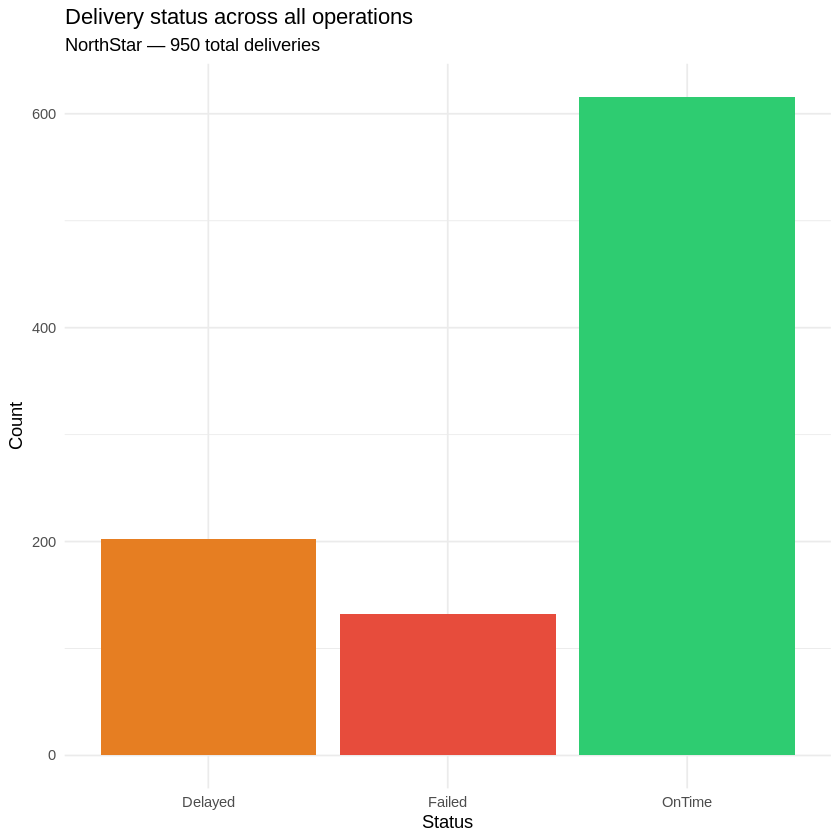

In [6]:
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  scale_fill_manual(values = c("OnTime" = "#2ecc71",
                               "Delayed" = "#e67e22",
                               "Failed"  = "#e74c3c")) +
  labs(
    title    = "Delivery status across all operations",
    subtitle = "NorthStar — 950 total deliveries",
    x        = "Status",
    y        = "Count"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

"Over one third of deliveries are not completed on time, with 132 outright failures. This volume of failure is unsustainable and directly links to rising customer complaints."

## Driver rating by employment type (boxplot)

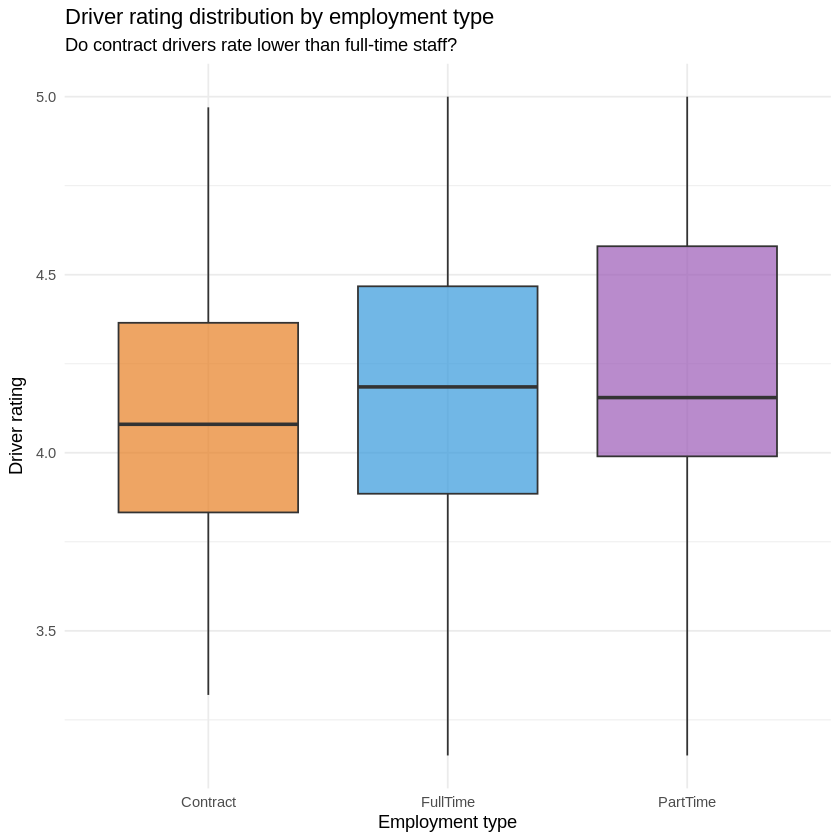

In [7]:
ggplot(drivers, aes(x = employment_type, y = driver_rating, fill = employment_type)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("FullTime"  = "#3498db",
                               "PartTime"  = "#9b59b6",
                               "Contract"  = "#e67e22")) +
  labs(
    title    = "Driver rating distribution by employment type",
    subtitle = "Do contract drivers rate lower than full-time staff?",
    x        = "Employment type",
    y        = "Driver rating"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

"Boxplots reveal whether rating spread differs across employment types. A wider spread for contract drivers would suggest inconsistent service quality from that workforce segment."

## Complaint types (horizontal bar)

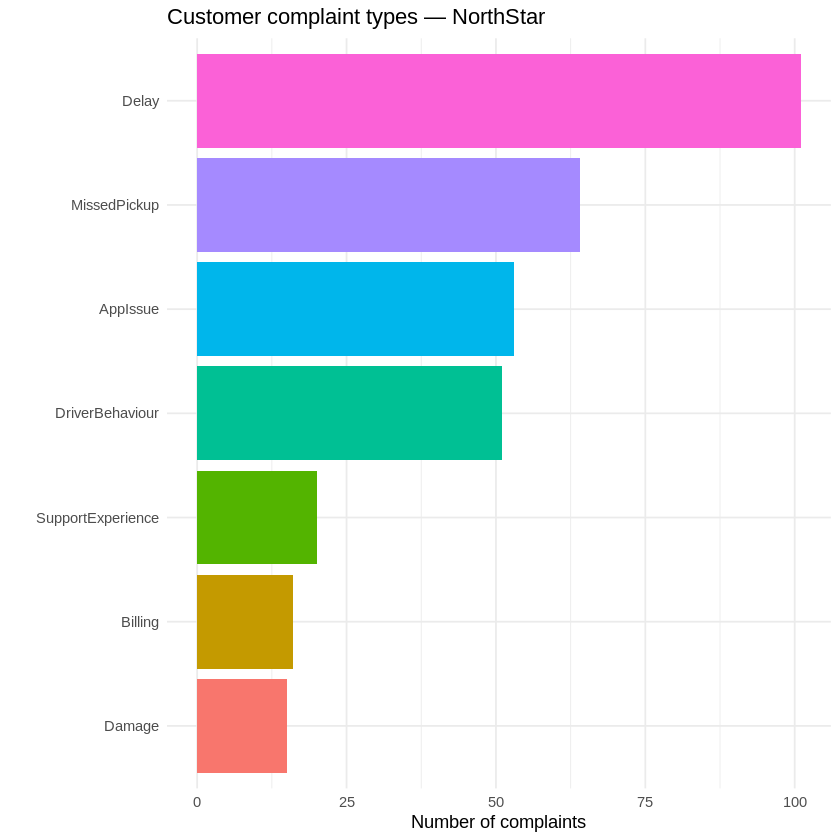

In [ ]:
complaints %>%
  group_by(complaint_type) %>%
  summarise(count = n()) %>%
  arrange(count) %>%
  mutate(complaint_type = factor(complaint_type, levels = complaint_type)) %>%

ggplot(aes(x = complaint_type, y = count, fill = complaint_type)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Customer complaint types — NorthStar",
    x     = NULL,
    y     = "Number of complaints"
  ) +
  theme_minimal()

"Delay is the single largest complaint category with 101 cases, followed by MissedPickup. Both are operationally preventable — this chart shows where NorthStar needs to focus first."

## Battery health by vehicle type (boxplot)

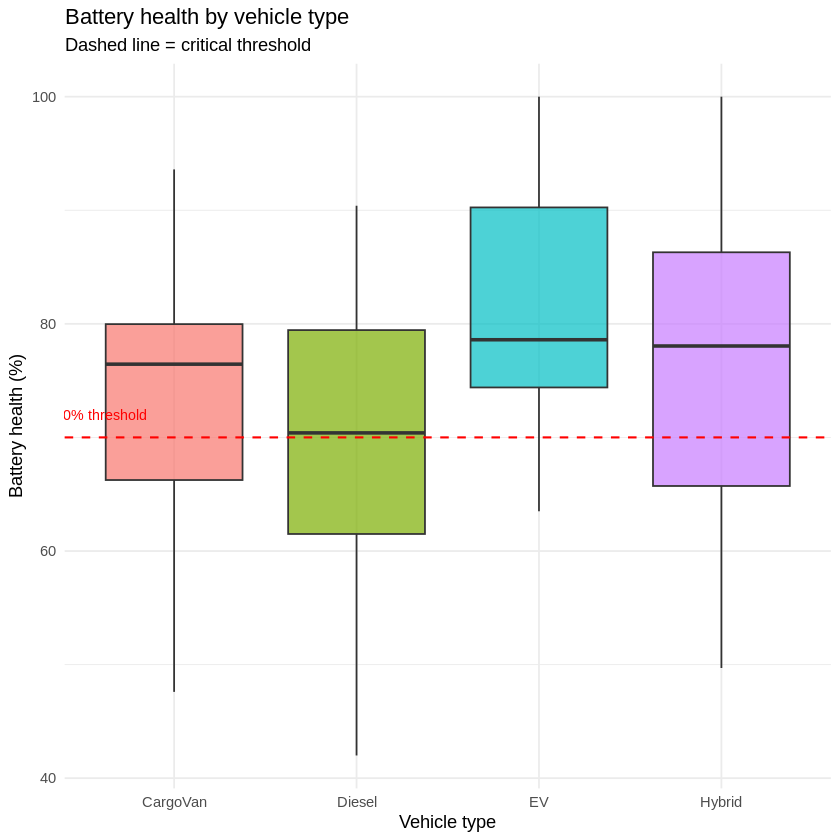

In [8]:
ggplot(vehicles, aes(x = vehicle_type, y = battery_health_pct, fill = vehicle_type)) +
  geom_boxplot(alpha = 0.7) +
  geom_hline(yintercept = 70, linetype = "dashed", color = "red", linewidth = 0.6) +
  annotate("text", x = 0.6, y = 72, label = "70% threshold", size = 3, color = "red") +
  labs(
    title    = "Battery health by vehicle type",
    subtitle = "Dashed line = critical threshold",
    x        = "Vehicle type",
    y        = "Battery health (%)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

"Several vehicles fall below the 70% battery health threshold across all types. EV vehicles below this level are most at risk of mid-route failures, which directly causes service delays."



## Customer loyalty score by account status (histogram)

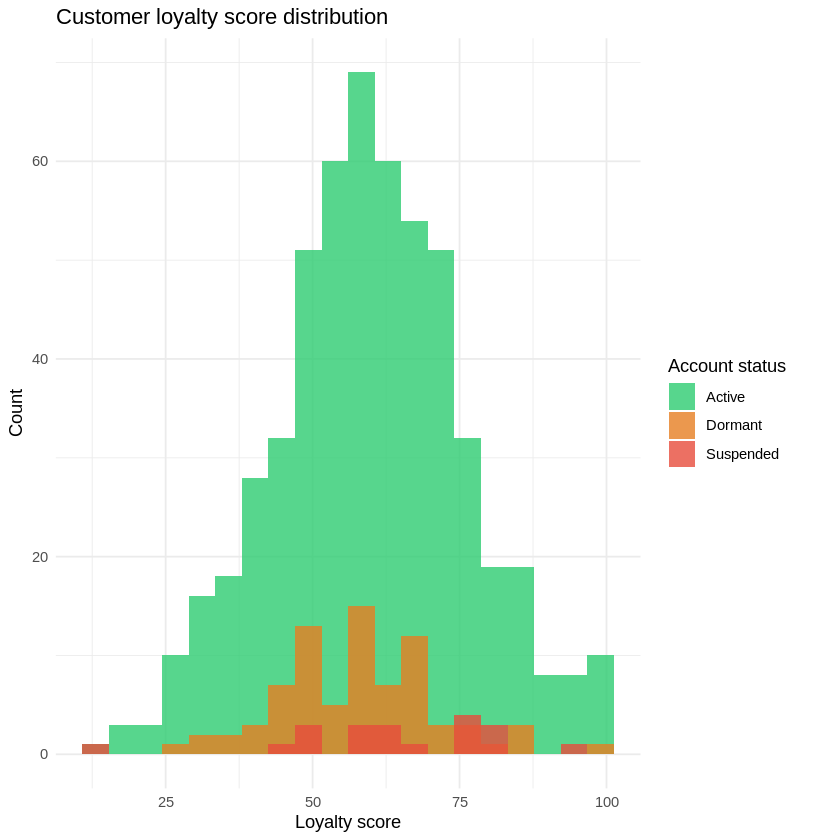

In [ ]:
ggplot(customers, aes(x = loyalty_score, fill = account_status)) +
  geom_histogram(bins = 20, alpha = 0.8, position = "identity") +
  scale_fill_manual(values = c("Active"    = "#2ecc71",
                               "Dormant"   = "#e67e22",
                               "Suspended" = "#e74c3c")) +
  labs(
    title = "Customer loyalty score distribution",
    x     = "Loyalty score",
    y     = "Count",
    fill  = "Account status"
  ) +
  theme_minimal()

"Dormant and suspended accounts tend to cluster at lower loyalty scores, suggesting that poor service experience drives customers inactive before they formally churn."